# TP1 INGENIEURIE DES DONNEES
## Victor Bouvier d'Acher

*Importation des bibliothèques*

In [116]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Données

In [117]:
iris = datasets.load_iris()

X = iris.data
y = iris.target

nb_desc = X.shape[1]
nb_ex = X.shape[0]
nb_classe = len(np.unique(y))

In [118]:
print(f'Il y a {nb_desc} descriptions.')
print(f'Il y a {nb_ex} d\'exemples.')
print(f'Il y a {nb_classe} classes.')

Il y a 4 descriptions.
Il y a 150 d'exemples.
Il y a 3 classes.


### 2. Analyse monodimensionnelle

- 1


In [119]:
moy = [round(np.mean(X[:,i]), 3) for i in range(nb_desc)]
var = [round(np.var(X[:,i]), 3) for i in range(nb_desc)]

In [120]:
print(f'La moyenne de chaque descripteur est {moy}.')
print(f'La variance de chaque descripteur est {var}.')

La moyenne de chaque descripteur est [5.843, 3.057, 3.758, 1.199].
La variance de chaque descripteur est [0.681, 0.189, 3.096, 0.577].


| | d1 | d2 | d3 | d4 |
|-|----|----|----|----|
|**moyenne**|5.843|3.057|3.758|1.199|
|**variance**|0.681|0.189|3.096|0.577|

- 2

Le **meilleur** descripteur est le **troisième** car il a la plus grande variance à savoir 3.096.  
Le **moins bon** descripteur est le **deuxième** car il a la plus petite variance à savoir 0.189.


### 3. Analyse conditionnelle

- 1

In [121]:
_, count = np.unique(y, return_counts=True)

In [122]:
classe_0 = X[0:50]
classe_1 = X[50:100]
classe_2 = X[100:150]

In [123]:
moy_classe_0 = [round(np.mean(classe_0[:,i]), 3) for i in range(nb_desc)]
moy_classe_1 = [round(np.mean(classe_1[:,i]), 3) for i in range(nb_desc)]
moy_classe_2 = [round(np.mean(classe_2[:,i]), 3) for i in range(nb_desc)]

var_classe_0 = [round(np.var(classe_0[:,i]), 3) for i in range(nb_desc)]
var_classe_1 = [round(np.var(classe_1[:,i]), 3) for i in range(nb_desc)]
var_classe_2 = [round(np.var(classe_2[:,i]), 3) for i in range(nb_desc)]

moy_classe = np.vstack((moy_classe_0, moy_classe_1, moy_classe_2))
var_classe = np.vstack((var_classe_0, var_classe_1, var_classe_2))

# print(moy_classe)
# print(var_classe)

moy_var_intra_classe = [round(np.mean(var_classe[:,i]), 3) for i in range(nb_desc)]

# print(moy_var_intra_classe}.)

Voici la moyenne conditionnelles de chaque classe:   
|moyenne| d1 | d2 | d3 | d4 |
|-|----|----|----|----|
|**classe 0**|5.006|3.428|1.462|0.246|
|**classe 1**|5.936|2.77|4.26|1.326|
|**classe 2**|6.588|2.974|5.552|2.026|  
  
Voici la variance conditionnelles de chaque classe:  
|variance| d1 | d2 | d3 | d4 |
|-|----|----|----|----|
|**classe 0**|0.122|0.141|0.03|0.011|
|**classe 1**|0.261|0.097|0.216|0.038|
|**classe 2**|0.396|0.102|0.298|0.074|

Voici la variance intra-classes de chaque descripteur:  
|variance| d1 | d2 | d3 | d4 |
|-|----|----|----|----|
|**intra-classe**|0.26|0.113|0.181|0.041|

- 2


In [124]:
var_moy_inter_classe = [round(np.var(moy_classe[:,i]), 3) for i in range(nb_desc)]
# print(var_moy_inter_classe)

Voici la variance inter-classes de chaque descripteur:  
|variance| d1 | d2 | d3 | d4 |
|-|----|----|----|----|
|**inter-classe**|0.421|0.076|2.914|0.536|

- 3

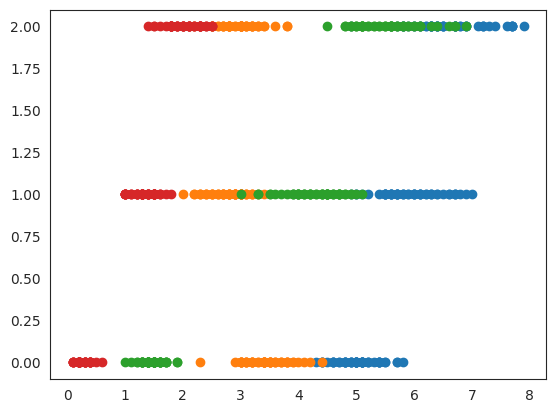

In [125]:
for i in range(nb_desc):
    plt.scatter(X[:,i], y)

- 4 

le **meilleur** descripteur est le descripteur **vert**  
le **moins bon** descripteur est le descripteur **orange**

### 4. Analyse bidimensionnelle

- 1

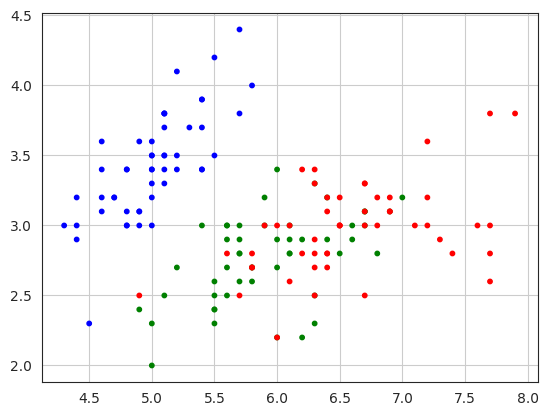

In [126]:
colors = np.array([x for x in "bgrcmyk"])
plt.scatter(X[:,0], X[:,1], color=colors[y].tolist(), s=10)
plt.grid()
plt.show()

On constate que la classe de point **rouge** et **verte** sont **mélangés**

- 2


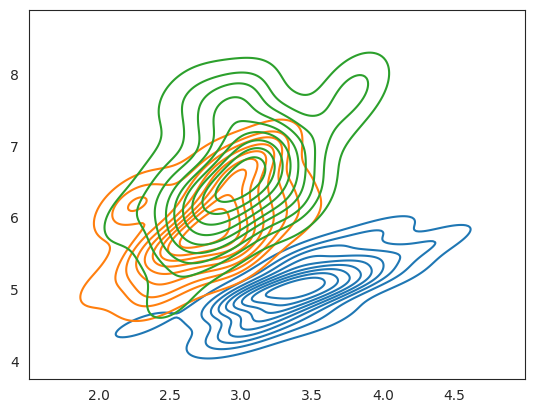

In [127]:
sns.set_style("white")

sns.kdeplot(y=classe_0[:,0], x=classe_0[:,1])
sns.kdeplot(y=classe_1[:,0], x=classe_1[:,1])
sns.kdeplot(y=classe_2[:,0], x=classe_2[:,1])
plt.show()
 

On remarque que la classe **orange** et **verte** sont **superposé**.

- 3

In [128]:
cov_classe_0 = np.cov(classe_0[:,0], classe_0[:,1])
cov_classe_1 = np.cov(classe_1[:,0], classe_1[:,1])
cov_classe_2 = np.cov(classe_2[:,0], classe_2[:,1])

# print(cov_classe_0)
# print(cov_classe_1)
# print(cov_classe_2)

|classe 0| d1 | d2 |
|--------|----|----|
|**d1**|0.124|0.099|
|**d2**|0.099|0.143|  

La covariance de la classe 0 par rapport au descripteur 1 et 2 est **0.099**.  

|classe 1| d1 | d2 |
|--------|----|----|
|**d1**|0.266|0.085|
|**d2**|0.085|0.098| 

La covariance de la classe 1 par rapport au descripteur 1 et 2 est **0.085**.  

|classe 2| d1 | d2 |
|--------|----|----|
|**d1**|0.404|0.093|
|**d2**|0.093|0.104|  

La covariance de la classe 2 par rapport au descripteur 1 et 2 est **0.093**.

- 4

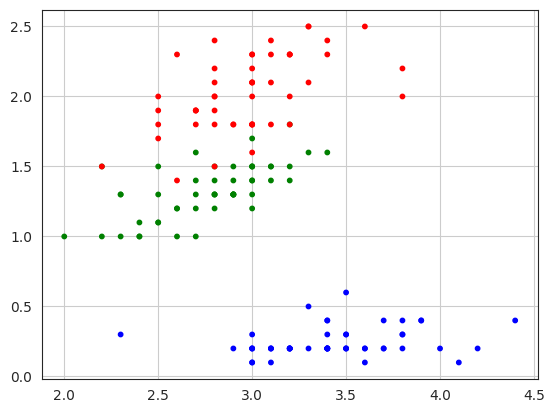

In [129]:
colors = np.array([x for x in "bgrcmyk"])
plt.scatter(X[:,1], X[:,3], color=colors[y].tolist(), s=10)
plt.grid()
plt.show()

On constate que chaque classe est **séparé l'une de l'autre**.

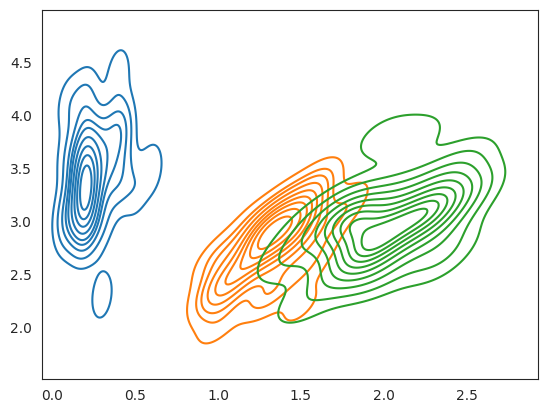

In [130]:
sns.set_style("white")

sns.kdeplot(y=classe_0[:,1], x=classe_0[:,3])
sns.kdeplot(y=classe_1[:,1], x=classe_1[:,3])
sns.kdeplot(y=classe_2[:,1], x=classe_2[:,3])
plt.show()

On remarque que la classe **verte** et **orange** sont mieux **séparé**.

In [131]:
cov_classe_0 = np.cov(classe_0[:,1], classe_0[:,3])
cov_classe_1 = np.cov(classe_1[:,1], classe_1[:,3])
cov_classe_2 = np.cov(classe_2[:,1], classe_2[:,3])

# print(cov_classe_0)
# print(cov_classe_1)
# print(cov_classe_2)

|classe 0| d2 | d4 |
|--------|----|----|
|**d2**|0.143|0.009|
|**d4**|0.009|0.111|  

La covariance de la classe 0 par rapport au descripteur 1 et 2 est **0.009**.  

|classe 1| d2 | d4 |
|--------|----|----|
|**d2**|0.0.98|0.041|
|**d4**|0.0.41|0.039| 

La covariance de la classe 1 par rapport au descripteur 1 et 2 est **0.041**.  

|classe 2| d2 | d4 |
|--------|----|----|
|**d2**|0.104|0.047|
|**d4**|0.047|0.075|  

La covariance de la classe 0 par rapport au descripteur 1 et 2 est **0.047**.

- 5

La paire de descripteur la plus adapatée pour faire la classification est la pair **d2, d4**
car la **covariance est plus faible**.

- 6

In [132]:
tab = []

for i in range(1000):

    X_train, X_test, y_train, y_test = train_test_split(X[:,[0, 1]], y, test_size=0.2)

    neigh = NearestNeighbors(n_neighbors=1)

    neigh.fit(X_train, y_train)

    k = neigh.kneighbors(X_test, return_distance=False)

    y_pred = y_train[k]

    tab.append(accuracy_score(y_pred, y_test))

In [133]:
print(f'La moyenne de la precision de la prediction est {round(np.mean(tab), 3)}')

La moyenne de la precision de la prediction est 0.717


In [134]:
tab2 = []

for i in range(1000):

    X_train, X_test, y_train, y_test = train_test_split(X[:,[1, 3]], y, test_size=0.2)

    neigh = NearestNeighbors(n_neighbors=1)

    neigh.fit(X_train, y_train)

    k = neigh.kneighbors(X_test, return_distance=False)

    y_pred = y_train[k]

    tab2.append(accuracy_score(y_pred, y_test))


In [135]:
print(f'La moyenne de la precision de la prediction est {round(np.mean(tab2), 3)}')

La moyenne de la precision de la prediction est 0.923


Après avoir tester les 2 differentes paires de descripteur, l'une est ressorti plus précise.  
La paire **d2, d4** qui à en moyenne une precision de prediction d'environ **0.92** qui est bien superieur à la paire **d1, d2** qui est d'environ **0.72**.  